Esta atividade é para vocês implementarem os modelos de DL (pode ser mais de um) escolhidos. O objetivo é que os grupos se familiarizem com a implementação destes modelos. Sugiro que vocês executem os modelos com apenas com uma base de dados de brinquedo, que é geralmente encontrada junto com a biblioteca escolhida (exemplo pytorch). Deste modo, vocês irão lidar com potenciais dúvidas sobre implementação logo cedo, antes de resolver o problema escolhido pelo grupo. Vocês poderão verificar se o modelo se comporta como esperado, validando-o para o seu problema. Além disso, vocês poderão adiantar qualquer dor de cabeça na implementação e tirar dúvidas com a maior antecedência possível. Apenas um integrante do grupo deve submeter a atividade no classroom.

vamos trabalhar com o dataset city spaces de preferência com segmentação

## importando bibliotecas

In [18]:
import sys
from pathlib import Path

NOTEBOOK_DIR = Path('/home/bruno/PROJETOS-IF687/quarta_atividade')
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import torch
from torch import nn
from torchvision import datasets
from torchvision.transforms import v2
from torch.utils.data import DataLoader, Subset
import torchvision.models as models
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import optuna
from fvcore.nn import FlopCountAnalysis
from plotly.io import show
from landmark_utils import normalize_landmarks, denormalize_landmarks


In [19]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

import numpy as np
import random
np.random.seed(SEED)
random.seed(SEED)

Using device: cuda


In [20]:
NUM_WORKERS = 2
PERSISTENT_WORKERS = True
NJOBS = 1
NUM_TRIALS = 25
DIFF_THRESHOLD = 0.1

## preparação do dataset

In [21]:
from landmark_utils import IMAGE_HEIGHT, IMAGE_WIDTH, normalize_landmarks, denormalize_landmarks

transform_target = normalize_landmarks
transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])

In [22]:
train_data = datasets.CelebA(root="./../datasets", split="train", target_type="landmarks", transform=transform, target_transform=transform_target, download=True)
test_data = datasets.CelebA(root="./../datasets", split="test", target_type="landmarks", transform=transform, target_transform=transform_target, download=True)
val_data = datasets.CelebA(root="./../datasets", split="valid", target_type="landmarks", transform=transform, target_transform=transform_target, download=True)

In [23]:
train_data = Subset(train_data, torch.randperm(len(train_data))[:2000])
test_data = Subset(test_data, torch.randperm(len(test_data))[:2000])
val_data = Subset(val_data, torch.randperm(len(val_data))[:2000])

In [24]:
print(f'Train samples: {len(train_data)}')
print(f'Test samples: {len(test_data)}')
print(f'Validation samples: {len(val_data)}')
print(f'Image shape: {train_data[0][0].shape}')

Train samples: 2000
Test samples: 2000
Validation samples: 2000
Image shape: torch.Size([3, 218, 178])


In [25]:
def visualize_landmarks(img, target):
    # Se a imagem vier como tensor [C, H, W]
    print("img bruto:", img.shape)
    print("target normalizado:", target)
    img_np = img.permute(1, 2, 0).numpy()

    landmarks = denormalize_landmarks(target).view(5, 2)
    labels = ["left eye", "right eye", "nose", "left mouth", "right mouth"]

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img_np)
    ax.scatter(landmarks[:, 0], landmarks[:, 1], c="cyan", s=40)

    for (x, y), label in zip(landmarks, labels):
        ax.annotate(
            label,
            (x, y),
            textcoords="offset points",
            xytext=(5, 5),
            color="yellow",
            fontsize=8,
            bbox=dict(facecolor="black", alpha=0.5, edgecolor="none", pad=1),
        )

    ax.set_title("CelebA landmarks")
    ax.axis("off")
    plt.show()

img bruto: torch.Size([3, 218, 178])
target normalizado: tensor([0.4045, 0.5046, 0.5955, 0.5046, 0.5056, 0.5872, 0.4157, 0.7110, 0.5787,
        0.7018])


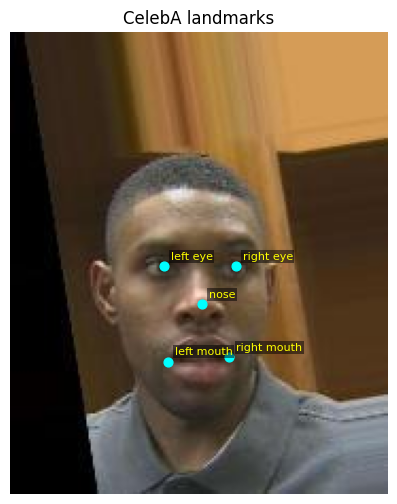

In [26]:
sample_index = torch.randint(0, len(train_data), (1,)).item()
img, target = train_data[sample_index]
visualize_landmarks(img, target)

## Códigos para treinamento, avaliação e plot

In [27]:
# função para avaliar o modelo no conjunto de teste
def evaluate_model(model, test_dataloader, metric_fn=metrics.mean_absolute_error, device=device):
    model.eval()
    y = []
    y_pred = []
    with torch.no_grad():
        for X_batch, y_batch in test_dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = model(X_batch)
            y.extend(y_batch.detach().cpu().tolist())
            y_pred.extend(outputs.detach().cpu().tolist())
    metric_val = metric_fn(y, y_pred)
    return metric_val

In [28]:
# função para treinar o modelo, recebe como entrada o modelo, os dataloaders de treino e validação, a função de perda, o otimizador e o número de épocas e o critério de parada
# a função também salva o histórico da função de perda para treino e validação
def train_model(model, train_dataloader, val_dataloader, loss_fn, optimizer, num_epochs, patience, metric_fn=None, device=device, verbose=False):
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    history_train_loss = []
    history_val_loss = []
    history_val_metric = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for X_batch, y_batch in train_dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_dataloader)
        history_train_loss.append(avg_train_loss)

        if verbose and epoch % 5 == 0:
            print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}')

        # validação
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_dataloader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                outputs = model(X_batch)
                loss = loss_fn(outputs, y_batch)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_dataloader)
        history_val_loss.append(avg_val_loss)

        if verbose and epoch % 5 == 0:
            print(f'Epoch {epoch+1}/{num_epochs}, Validation Loss: {avg_val_loss:.4f}')

        # avaliando a métrica de validação
        if metric_fn is not None:
            metric_val = evaluate_model(model, val_dataloader, metric_fn=metric_fn, device=device)
            history_val_metric.append(metric_val)
            if verbose and epoch % 5 == 0:
                print(f'Epoch {epoch+1}/{num_epochs}, Validation Metric: {metric_val:.4f}')

        # critério de parada
        if (avg_val_loss + DIFF_THRESHOLD) < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    return history_train_loss, history_val_loss, history_val_metric

In [29]:
def plot_loss_graph(history_train_loss, history_val_loss, history_val_metric):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history_train_loss, label='Train Loss')
    ax1.plot(history_val_loss, label='Val Loss')
    ax1.set_xlabel('Epochs'); ax1.set_ylabel('Loss')
    ax1.set_title('Loss'); ax1.legend()

    if history_val_metric:
        ax2.plot(history_val_metric, label='Val MAE', color='green')
        ax2.set_xlabel('Epochs'); ax2.set_ylabel('MAE')
        ax2.set_title('Validation MAE'); ax2.legend()
    plt.tight_layout(); plt.show()

## Códigos para CNN e otimização de hiperparâmetros

In [30]:
map_activation_functions = {
    'relu': nn.ReLU,
    'sigmoid': nn.Sigmoid,
    'tanh': nn.Tanh,
    'leaky_relu': nn.LeakyReLU,
}
map_optimizers = {
    'adam': torch.optim.Adam,
    'sgd': torch.optim.SGD,
    'rmsprop': torch.optim.RMSprop,
    'adagrad': torch.optim.Adagrad
}
def get_activation_function(name):
    return map_activation_functions[name]()

In [31]:
class CNNParameters:
    def __init__(self, num_conv_layers, stride_conv_layers, input_channels, out_channels_list, use_pooling,
                 padding_conv_layer, dilatation, bias, kernel_size, kernel_stride,
                 kernel_padding, kernel_dilatation, activation_function_conv, fully_connected_layers_list,
                 activation_function_fully_connected, dropout_rate_fully_connected, dropout_rate_conv, output_size_fully_connected,
                 image_size_height, image_size_width, use_normalization
                 ):
        
        # cnn parameters
        self.num_conv_layers = num_conv_layers
        self.stride_conv_layers = stride_conv_layers
        self.input_channels = input_channels
        self.out_channels_list = out_channels_list
        self.dropout_rate_conv = dropout_rate_conv
        self.padding_conv_layer = padding_conv_layer
        self.dilatation = dilatation
        self.bias = bias
        self.activation_function_conv = activation_function_conv
        self.use_normalization = use_normalization

        # polling parameters
        self.use_pooling = use_pooling
        self.kernel_size = kernel_size
        self.kernel_stride = kernel_stride
        self.kernel_padding = kernel_padding
        self.kernel_dilatation = kernel_dilatation

        # fully connected layers parameters
        self.fully_connected_layers_list = fully_connected_layers_list
        self.activation_function_fully_connected = activation_function_fully_connected
        self.dropout_rate_fully_connected = dropout_rate_fully_connected
        self.output_size_fully_connected = output_size_fully_connected

        #flatten size
        self.image_size_height = image_size_height
        self.image_size_width = image_size_width
        self.image_size_height_output = 0
        self.image_size_width_output = 0
        self.image_size_height_output, self.image_size_width_output = self._calculate_output_size(image_size_height, image_size_width)
        self.flatten_size = self.image_size_height_output * self.image_size_width_output * self.out_channels_list[-1]

    def _calculate_output_size(self, input_size_height, input_size_width):
        output_size_height = input_size_height
        output_size_width = input_size_width
        for i in range(self.num_conv_layers):
            output_size_height = (output_size_height + 2 * self.padding_conv_layer - self.dilatation * (self.kernel_size - 1) - 1) // self.stride_conv_layers + 1
            output_size_width = (output_size_width + 2 * self.padding_conv_layer - self.dilatation * (self.kernel_size - 1) - 1) // self.stride_conv_layers + 1
            if self.use_pooling:
                output_size_height = (output_size_height + 2 * self.kernel_padding - self.kernel_dilatation * (self.kernel_size - 1) - 1) // self.kernel_stride + 1
                output_size_width = (output_size_width + 2 * self.kernel_padding - self.kernel_dilatation * (self.kernel_size - 1) - 1) // self.kernel_stride + 1
        return output_size_height, output_size_width

In [32]:
class CNN(nn.Module):
    def __init__(self, cnn_parameters: CNNParameters):
        super(CNN, self).__init__()
        self.cnn_parameters = cnn_parameters

        layers = []

        for i in range(self.cnn_parameters.num_conv_layers):
            layers.append(nn.Conv2d(in_channels=self.cnn_parameters.input_channels if i == 0 else self.cnn_parameters.out_channels_list[i-1],
                                    out_channels=self.cnn_parameters.out_channels_list[i],
                                    kernel_size=self.cnn_parameters.kernel_size,
                                    stride=self.cnn_parameters.stride_conv_layers,
                                    padding=self.cnn_parameters.padding_conv_layer,
                                    dilation=self.cnn_parameters.dilatation,
                                    bias=self.cnn_parameters.bias))
            layers.append(get_activation_function(self.cnn_parameters.activation_function_conv))

            if self.cnn_parameters.use_normalization:
                layers.append(nn.BatchNorm2d(self.cnn_parameters.out_channels_list[i], device=device))

            if self.cnn_parameters.dropout_rate_conv > 0:
                layers.append(nn.Dropout2d(self.cnn_parameters.dropout_rate_conv))

            if self.cnn_parameters.use_pooling:
                layers.append(nn.MaxPool2d(kernel_size=self.cnn_parameters.kernel_size,
                                           stride=self.cnn_parameters.kernel_stride,
                                           padding=self.cnn_parameters.kernel_padding,
                                           dilation=self.cnn_parameters.kernel_dilatation))
        
        self.conv_layers = nn.Sequential(*layers)
        
        fully_connected_layers = []
        input_size_fully_connected = cnn_parameters.flatten_size

        for output_size in self.cnn_parameters.fully_connected_layers_list:
            fully_connected_layers.append(nn.Linear(input_size_fully_connected, output_size))
            fully_connected_layers.append(get_activation_function(self.cnn_parameters.activation_function_fully_connected))
            if self.cnn_parameters.dropout_rate_fully_connected > 0:
                fully_connected_layers.append(nn.Dropout(self.cnn_parameters.dropout_rate_fully_connected))
            input_size_fully_connected = output_size
        
        fully_connected_layers.append(nn.Linear(input_size_fully_connected, self.cnn_parameters.output_size_fully_connected))
        self.fully_connected_layers = nn.Sequential(*fully_connected_layers)

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.flatten(start_dim=1)
        x = self.fully_connected_layers(x)
        return x
            
        

In [33]:
# função para criação do modelo, e definição dos hiperparâmetros do modelo e dataloaders
def create_cnn_model_and_dataloaders( cnn_parameters,train_data, test_data, val_data, batch_size):
    model = CNN(cnn_parameters)
    train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS, persistent_workers=PERSISTENT_WORKERS)
    test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, persistent_workers=PERSISTENT_WORKERS)
    val_dataloader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, persistent_workers=PERSISTENT_WORKERS)
    return model, train_dataloader, test_dataloader, val_dataloader

In [40]:
def objectiveCelebA(trial):
    """
    Otimiza uma CNN pequena para CelebA para regressão de landmarks, procurando
    um compromisso entre menor erro nas coordenadas e menor complexidade do modelo.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    num_conv_layers = trial.suggest_int('num_conv_layers', 1, 3)
    
    out_channels_list = []
    for i in range(num_conv_layers):
        out_channels = trial.suggest_int(f'out_channels_layer_{i}', 3, 32)
        out_channels_list.append(out_channels)

    kernel_size = trial.suggest_int('kernel_size', 3, 5)
    stride_conv = trial.suggest_categorical('stride_conv', [1, 2])
    padding_conv = trial.suggest_categorical('padding_conv', [0, 1, 2])
    dilatation = 1
    bias = True

    use_pooling = trial.suggest_categorical('use_pooling', [True, False])
    kernel_stride_pool = 1
    kernel_padding_pool = 0
    kernel_dilatation_pool = 1

    activation_function_conv = trial.suggest_categorical('activation_function_conv', ['relu', 'leaky_relu', 'tanh'])
    use_dropout_conv = trial.suggest_categorical('use_dropout_conv', [True, False])
    if use_dropout_conv:
        dropout_rate_conv = trial.suggest_float('dropout_rate_conv', 0.2, 0.6)
    else:
        dropout_rate_conv = 0.0

    use_normalization = trial.suggest_categorical('use_normalization', [True, False])

    num_fc_layers = trial.suggest_int('num_fc_layers', 1, 3)
    fully_connected_layers_list = []
    for i in range(num_fc_layers):
        fc_units = trial.suggest_int(f'fc_units_{i}', 8, 256)
        fully_connected_layers_list.append(fc_units)

    activation_function_fc = trial.suggest_categorical('activation_function_fc', ['relu', 'leaky_relu', 'tanh', 'sigmoid'])
    use_dropout_fc = trial.suggest_categorical('use_dropout_fc', [True, False])
    if use_dropout_fc:
        dropout_rate_fc = trial.suggest_float('dropout_rate_fc', 0.2, 0.6)
    else:
        dropout_rate_fc = 0.0

    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128, 256])
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 5e-2, log=True)
    optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'sgd', 'rmsprop'])
    use_weight_decay = trial.suggest_categorical('use_weight_decay', [True, False])
    if use_weight_decay:
        weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    else:
        weight_decay = 0.0
    num_epochs = 10000
    patience = 15

    try:
        img_shape = train_data[0][0].shape  # (C, H, W)
        image_size_height=img_shape[1]
        image_size_width=img_shape[2]
        cnn_params = CNNParameters(
            num_conv_layers=num_conv_layers,
            stride_conv_layers=stride_conv,
            input_channels=3,
            out_channels_list=out_channels_list,
            use_pooling=use_pooling,
            padding_conv_layer=padding_conv,
            dilatation=dilatation,
            bias=bias,
            kernel_size=kernel_size,
            kernel_stride=kernel_stride_pool,
            kernel_padding=kernel_padding_pool,
            kernel_dilatation=kernel_dilatation_pool,
            activation_function_conv=activation_function_conv,
            fully_connected_layers_list=fully_connected_layers_list,
            activation_function_fully_connected=activation_function_fc,
            dropout_rate_fully_connected=dropout_rate_fc,
            dropout_rate_conv=dropout_rate_conv,
            output_size_fully_connected=10,
            image_size_height=image_size_height,
            image_size_width=image_size_width,
            use_normalization=use_normalization
        )

        if cnn_params.image_size_height_output <= 0 or cnn_params.image_size_width_output <= 0:
            return 0.0, float('inf')

        model, train_dataloader, test_dataloader, val_dataloader = create_cnn_model_and_dataloaders(
            cnn_params, train_data, test_data, val_data, batch_size
        )
        model = model.to(device)

        loss_fn = nn.SmoothL1Loss()
        optimizer_cls = map_optimizers[optimizer_name]

        if optimizer_name == 'sgd':
            use_momentum = trial.suggest_categorical('use_momentum', [True, False])
            if use_momentum:
                momentum = trial.suggest_float('momentum', 0.5, 0.9)
                use_nesterov = trial.suggest_categorical('use_nesterov', [True, False])
            else:
                momentum = 0.0
                use_nesterov = False
            optimizer = optimizer_cls(model.parameters(), lr=learning_rate, momentum=momentum, weight_decay=weight_decay, nesterov=use_nesterov)
        elif optimizer_name == 'adagrad':
            use_initial_accumulator_value = trial.suggest_categorical('use_initial_accumulator_value', [True, False])
            if use_initial_accumulator_value:
                initial_accumulator_value = trial.suggest_float('initial_accumulator_value', 1e-8, 1e-4, log=True)
            else:
                initial_accumulator_value = 0.1 
            use_lr_decay = trial.suggest_categorical('use_lr_decay', [True, False])
            if use_lr_decay:
                lr_decay = trial.suggest_float('lr_decay', 0.0, 1e-2, log=True)
                optimizer = optimizer_cls(model.parameters(), lr=learning_rate, weight_decay=weight_decay, initial_accumulator_value=initial_accumulator_value, lr_decay=lr_decay)
            else:
                optimizer = optimizer_cls(model.parameters(), lr=learning_rate, weight_decay=weight_decay, initial_accumulator_value=initial_accumulator_value)
        elif optimizer_name == 'adam':
            use_betas = trial.suggest_categorical('use_betas', [True, False])
            if use_betas:
                beta1 = trial.suggest_float('beta1', 0.8, 0.99)
                beta2 = trial.suggest_float('beta2', 0.9, 0.999)
                optimizer = optimizer_cls(model.parameters(), lr=learning_rate, weight_decay=weight_decay, betas=(beta1, beta2))
            else:
                optimizer = optimizer_cls(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        else:
            use_momentum = trial.suggest_categorical('use_momentum', [True, False])
            if use_momentum:
                momentum = trial.suggest_float('momentum', 0.5, 0.9)
            else:
                momentum = 0.0
            optimizer = optimizer_cls(model.parameters(), lr=learning_rate, weight_decay=weight_decay, momentum=momentum)

        history_train_loss, history_val_loss, history_val_metric = train_model(
            model,
            train_dataloader,
            val_dataloader,
            loss_fn,
            optimizer,
            num_epochs=num_epochs,
            patience=patience,
            metric_fn=metrics.mean_absolute_error,
            device=device,
        )

        val_mae = evaluate_model(model, val_dataloader, metric_fn=metrics.mean_absolute_error, device=device)
        flops = FlopCountAnalysis(model.cpu(), torch.randn(1, img_shape[0], img_shape[1], img_shape[2]).cpu()).total()

        return val_mae, flops

    except Exception as e:
        print(f"Erro durante a execução do trial: {e}")
        return 0.0, float('inf')

## execução do treinamento da CNN

In [35]:
sampler = optuna.samplers.TPESampler(seed=SEED)
study_celeba = optuna.create_study(directions=['minimize', 'minimize'], sampler=sampler)
study_celeba.optimize(objectiveCelebA, n_trials=NUM_TRIALS, show_progress_bar=True, n_jobs=NJOBS)

[I 2026-05-28 20:20:54,237] A new study created in memory with name: no-name-1edfba6a-4a26-4267-b206-415adf359c7c
  0%|          | 0/25 [00:00<?, ?it/s]Unsupported operator aten::max_pool2d encountered 2 time(s)
Unsupported operator aten::sigmoid encountered 2 time(s)
  4%|▍         | 1/25 [04:31<1:48:35, 271.46s/it]

[I 2026-05-28 20:25:25,699] Trial 0 finished with values: [0.24875522442664955, 564361488.0] and parameters: {'num_conv_layers': 2, 'out_channels_layer_0': 31, 'out_channels_layer_1': 24, 'kernel_size': 4, 'stride_conv': 1, 'padding_conv': 1, 'use_pooling': True, 'activation_function_conv': 'relu', 'use_dropout_conv': False, 'use_normalization': False, 'num_fc_layers': 2, 'fc_units_0': 80, 'fc_units_1': 160, 'activation_function_fc': 'sigmoid', 'use_dropout_fc': True, 'dropout_rate_fc': 0.4056937753654446, 'batch_size': 128, 'learning_rate': 0.00014982086432155476, 'optimizer': 'sgd', 'use_weight_decay': True, 'weight_decay': 0.00011290133559092664, 'use_momentum': True, 'momentum': 0.6980707640445081, 'use_nesterov': False}.


Unsupported operator aten::leaky_relu encountered 1 time(s)
Unsupported operator aten::feature_dropout encountered 1 time(s)
Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::sigmoid encountered 3 time(s)
  8%|▊         | 2/25 [06:15<1:06:23, 173.20s/it]

[I 2026-05-28 20:27:10,111] Trial 1 finished with values: [0.01289104309529066, 25869679.0] and parameters: {'num_conv_layers': 1, 'out_channels_layer_0': 22, 'kernel_size': 3, 'stride_conv': 2, 'padding_conv': 1, 'use_pooling': True, 'activation_function_conv': 'leaky_relu', 'use_dropout_conv': True, 'dropout_rate_conv': 0.33013213230530575, 'use_normalization': True, 'num_fc_layers': 3, 'fc_units_0': 96, 'fc_units_1': 77, 'fc_units_2': 143, 'activation_function_fc': 'sigmoid', 'use_dropout_fc': True, 'dropout_rate_fc': 0.20220884684944096, 'batch_size': 32, 'learning_rate': 0.0001584325068438869, 'optimizer': 'rmsprop', 'use_weight_decay': True, 'weight_decay': 1.5512259126484753e-06, 'use_momentum': False}.


Unsupported operator aten::leaky_relu encountered 3 time(s)
Unsupported operator aten::feature_dropout encountered 3 time(s)
Unsupported operator aten::max_pool2d encountered 3 time(s)
Unsupported operator aten::sigmoid encountered 2 time(s)
 12%|█▏        | 3/25 [07:30<47:00, 128.23s/it]  

...

[I 2026-05-28 21:10:36,817] Trial 22 finished with values: [0.010248690369725227, 338324310.0] and parameters: {'num_conv_layers': 3, 'out_channels_layer_0': 11, 'out_channels_layer_1': 17, 'out_channels_layer_2': 25, 'kernel_size': 3, 'stride_conv': 1, 'padding_conv': 0, 'use_pooling': False, 'activation_function_conv': 'relu', 'use_dropout_conv': False, 'use_normalization': False, 'num_fc_layers': 1, 'fc_units_0': 137, 'activation_function_fc': 'relu', 'use_dropout_fc': False, 'batch_size': 64, 'learning_rate': 0.017472758478485496, 'optimizer': 'adam', 'use_weight_decay': False, 'use_betas': False}.


 96%|█████████▌| 24/25 [52:13<02:36, 156.81s/it]

[I 2026-05-28 21:13:07,600] Trial 23 finished with values: [0.009881567201018335, 341830257.0] and parameters: {'num_conv_layers': 3, 'out_channels_layer_0': 17, 'out_channels_layer_1': 14, 'out_channels_layer_2': 15, 'kernel_size': 4, 'stride_conv': 1, 'padding_conv': 0, 'use_pooling': False, 'activation_function_conv': 'relu', 'use_dropout_conv': False, 'use_normalization': False, 'num_fc_layers': 3, 'fc_units_0': 101, 'fc_units_1': 230, 'fc_units_2': 251, 'activation_function_fc': 'relu', 'use_dropout_fc': False, 'batch_size': 64, 'learning_rate': 0.007221304022715027, 'optimizer': 'adam', 'use_weight_decay': False, 'use_betas': False}.


Unsupported operator aten::leaky_relu encountered 2 time(s)
100%|██████████| 25/25 [57:04<00:00, 136.98s/it]

[I 2026-05-28 21:17:58,693] Trial 24 finished with values: [0.013719923499226568, 445541534.0] and parameters: {'num_conv_layers': 3, 'out_channels_layer_0': 17, 'out_channels_layer_1': 19, 'out_channels_layer_2': 13, 'kernel_size': 4, 'stride_conv': 1, 'padding_conv': 0, 'use_pooling': False, 'activation_function_conv': 'relu', 'use_dropout_conv': False, 'use_normalization': False, 'num_fc_layers': 2, 'fc_units_0': 189, 'fc_units_1': 107, 'activation_function_fc': 'leaky_relu', 'use_dropout_fc': False, 'batch_size': 256, 'learning_rate': 0.022199347098903435, 'optimizer': 'adam', 'use_weight_decay': False, 'use_betas': True, 'beta1': 0.949081052952738, 'beta2': 0.9456359001761895}.


## plots treinamento do melhor modelo

In [36]:
fig = optuna.visualization.plot_param_importances(study_celeba, target=lambda t: t.values[0], target_name='Validation MAE')
fig.update_layout(title='Importância dos Hiperparâmetros para Validação MAE')
show(fig)

In [37]:
best_model = min(study_celeba.best_trials, key=lambda t: t.values[0])
print(f"Best trial by validation MAE: MAE={best_model.values[0]:.4f}, complexidade={best_model.values[1]:.4f}, params={best_model.params}")


Best trial by validation MAE: MAE=0.0000, complexidade=inf, params={'num_conv_layers': 2, 'out_channels_layer_0': 12, 'out_channels_layer_1': 18, 'kernel_size': 3, 'stride_conv': 1, 'padding_conv': 0, 'use_pooling': True, 'activation_function_conv': 'relu', 'use_dropout_conv': True, 'dropout_rate_conv': 0.20492446782597498, 'use_normalization': False, 'num_fc_layers': 3, 'fc_units_0': 120, 'fc_units_1': 249, 'fc_units_2': 21, 'activation_function_fc': 'leaky_relu', 'use_dropout_fc': False, 'batch_size': 64, 'learning_rate': 0.03407638668046502, 'optimizer': 'sgd', 'use_weight_decay': False, 'use_momentum': False, 'use_nesterov': True}


In [41]:
best_params = best_model.params
cnn_params = CNNParameters(
    num_conv_layers=best_params['num_conv_layers'],
    stride_conv_layers=best_params['stride_conv'],
    input_channels=3,
    out_channels_list=[best_params[f'out_channels_layer_{i}'] for i in range(best_params['num_conv_layers'])],
    use_pooling=best_params['use_pooling'],
    padding_conv_layer=best_params['padding_conv'],
    dilatation=1,
    bias=True,
    kernel_size=best_params['kernel_size'],
    kernel_stride=1,
    kernel_padding=0,
    kernel_dilatation=1,
    activation_function_conv=best_params['activation_function_conv'],
    fully_connected_layers_list=[best_params[f'fc_units_{i}'] for i in range(best_params['num_fc_layers'])],
    activation_function_fully_connected=best_params['activation_function_fc'],
    dropout_rate_fully_connected=best_params['dropout_rate_fc'] if best_params['use_dropout_fc'] else 0.0,
    dropout_rate_conv=best_params['dropout_rate_conv'] if best_params['use_dropout_conv'] else 0.0,
    output_size_fully_connected=10,
    image_size_height=IMAGE_HEIGHT,
    image_size_width=IMAGE_WIDTH,
    use_normalization=best_params['use_normalization']
)
model, train_dataloader, test_dataloader, val_dataloader = create_cnn_model_and_dataloaders(
    cnn_params, train_data, test_data, val_data, best_params['batch_size']
)
model = model.to(device)
loss_fn = nn.SmoothL1Loss()
optimizer_cls = map_optimizers[best_params['optimizer']]
weight_decay = best_params.get('weight_decay', 0.0) if best_params.get('use_weight_decay', False) else 0.0
if best_params['optimizer'] == 'sgd':
    momentum = best_params['momentum'] if best_params['use_momentum'] else 0.0
    use_nesterov = best_params.get('use_nesterov', False) and momentum > 0
    optimizer = optimizer_cls(model.parameters(), lr=best_params['learning_rate'], momentum=momentum, weight_decay=weight_decay, nesterov=use_nesterov)
elif best_params['optimizer'] == 'adagrad':
    initial_accumulator_value = best_params['initial_accumulator_value'] if best_params['use_initial_accumulator_value'] else 0.1
    if best_params['use_lr_decay']:
        lr_decay = best_params['lr_decay']
        optimizer = optimizer_cls(model.parameters(), lr=best_params['learning_rate'], weight_decay=weight_decay, initial_accumulator_value=initial_accumulator_value, lr_decay=lr_decay)
    else:
        optimizer = optimizer_cls(model.parameters(), lr=best_params['learning_rate'], weight_decay=weight_decay, initial_accumulator_value=initial_accumulator_value)
elif best_params['optimizer'] == 'adam':
    betas = (best_params['beta1'], best_params['beta2']) if best_params['use_betas'] else (0.9, 0.999)
    optimizer = optimizer_cls(model.parameters(), lr=best_params['learning_rate'], weight_decay=weight_decay, betas=betas)
else:
    momentum = best_params['momentum'] if best_params['use_momentum'] else 0.0
    optimizer = optimizer_cls(model.parameters(), lr=best_params['learning_rate'], weight_decay=weight_decay, momentum=momentum)
history_train_loss, history_val_loss, history_val_metric = train_model(
    model,
    train_dataloader,
    val_dataloader,
    loss_fn,
    optimizer,
    num_epochs=10000,
    patience=15,
    metric_fn=metrics.mean_absolute_error,
    device=device,
    verbose=True
)


Epoch 1/10000, Train Loss: 0.0577
Epoch 1/10000, Validation Loss: 0.0066
Epoch 1/10000, Validation Metric: 0.0975
Epoch 6/10000, Train Loss: 0.0052
Epoch 6/10000, Validation Loss: 0.0042
Epoch 6/10000, Validation Metric: 0.0839
Epoch 11/10000, Train Loss: 0.0038
Epoch 11/10000, Validation Loss: 0.0030
Epoch 11/10000, Validation Metric: 0.0702
Epoch 16/10000, Train Loss: 0.0030
Epoch 16/10000, Validation Loss: 0.0044
Epoch 16/10000, Validation Metric: 0.0870


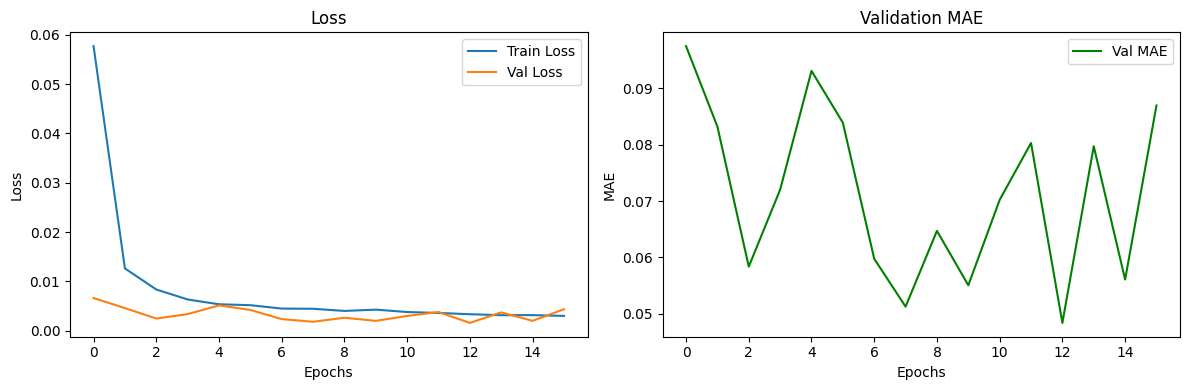

In [42]:
plot_loss_graph(history_train_loss, history_val_loss, history_val_metric)

In [43]:
torch.save(model.state_dict(), 'best_cnn_celeba.pth')

## Código para resnet18 

In [44]:
resnet_18_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).to(device)
resnet_18_model.fc = nn.Linear(resnet_18_model.fc.in_features, 10).to(device)

loss_fn = nn.SmoothL1Loss()
optimizer = torch.optim.Adam(resnet_18_model.parameters(), lr=1e-4, weight_decay=1e-5)



Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/luis/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 32.5MB/s]


In [45]:
transform_vit = v2.Compose([
    v2.Resize((224, 224)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

train_data_vit = datasets.CelebA(root="./../datasets", split="train", target_type="landmarks", transform=transform_vit, target_transform=transform_target, download=True)
test_data_vit = datasets.CelebA(root="./../datasets", split="test", target_type="landmarks", transform=transform_vit, target_transform=transform_target, download=True)
val_data_vit = datasets.CelebA(root="./../datasets", split="valid", target_type="landmarks", transform=transform_vit, target_transform=transform_target, download=True)

train_data_vit = Subset(train_data_vit, torch.randperm(len(train_data_vit))[:2000])
test_data_vit = Subset(test_data_vit, torch.randperm(len(test_data_vit))[:2000])
val_data_vit = Subset(val_data_vit, torch.randperm(len(val_data_vit))[:2000])

train_dataloader = DataLoader(train_data_vit, batch_size=64, shuffle=True, num_workers=NUM_WORKERS, persistent_workers=PERSISTENT_WORKERS)
val_dataloader = DataLoader(val_data_vit, batch_size=64, shuffle=False, num_workers=NUM_WORKERS, persistent_workers=PERSISTENT_WORKERS)

In [46]:
history_train_loss, history_val_loss, history_val_metric = train_model(
    resnet_18_model,
    train_dataloader,
    val_dataloader,
    loss_fn,
    optimizer,
    num_epochs=100,
    patience=15,
    metric_fn=metrics.mean_absolute_error,
    device=device,
    verbose=True
)

Epoch 1/100, Train Loss: 0.0685
Epoch 1/100, Validation Loss: 0.0178
Epoch 1/100, Validation Metric: 0.1517
Epoch 6/100, Train Loss: 0.0003
Epoch 6/100, Validation Loss: 0.0009
Epoch 6/100, Validation Metric: 0.0330
Epoch 11/100, Train Loss: 0.0001
Epoch 11/100, Validation Loss: 0.0006
Epoch 11/100, Validation Metric: 0.0261
Epoch 16/100, Train Loss: 0.0001
Epoch 16/100, Validation Loss: 0.0004
Epoch 16/100, Validation Metric: 0.0233


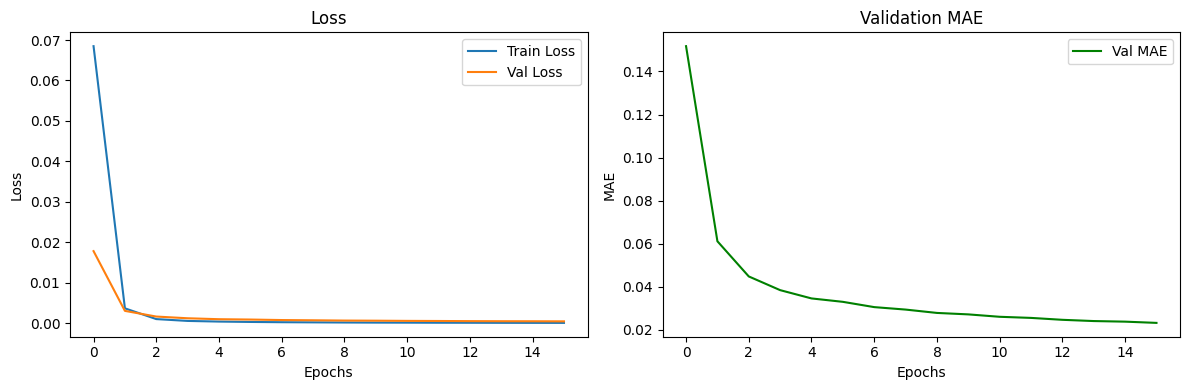

In [47]:
plot_loss_graph(history_train_loss, history_val_loss, history_val_metric)

In [48]:
torch.save(resnet_18_model.state_dict(), 'best_resnet18_celeba.pth')

## Comparação entre as duas redes nos conjunto de teste

In [49]:
resultado_cnn = evaluate_model(model, test_dataloader, metric_fn=metrics.mean_absolute_error, device=device)
resultado_resnet18 = evaluate_model(resnet_18_model, test_dataloader, metric_fn=metrics.mean_absolute_error, device=device)

print(f"Test MAE - CNN: {resultado_cnn:.4f}")
print(f"Test MAE - ResNet18: {resultado_resnet18:.4f}")

Test MAE - CNN: 0.0855
Test MAE - ResNet18: 0.0301
